In [1]:
import os
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "4")
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.inspection import permutation_importance

In [2]:
PLANT = 1
OUT = Path(r"C:\Users\VICTUS\Documents\College\Semester 3\Machine Learning\Solar Power Generation Data\processed")
FIG = OUT.parent / "figures"
FIG.mkdir(exist_ok=True)
 
P = pd.read_csv(OUT / f"plant{PLANT}_predictions.csv", index_col="DATE_TIME",
                parse_dates=["DATE_TIME", "target_time"])
X = pd.read_csv(OUT / f"plant{PLANT}_features.csv", index_col="DATE_TIME",
                parse_dates=["DATE_TIME", "target_time"])
sets = json.load(open(OUT / "feature_sets.json"))
best = json.load(open(OUT / "best_params.json"))
 
rmse = lambda y, p: float(np.sqrt(np.mean((np.asarray(y) - np.asarray(p)) ** 2)))
mae = lambda y, p: float(np.mean(np.abs(np.asarray(y) - np.asarray(p))))

ref = P[(P["setup"] == "A_lagged_only") & (P["model"] == "RF")]
y = ref["y_true"]

In [3]:
rows = [
    {"setup": "baseline", "model": "Persistence (same as now)",
     "RMSE": rmse(y, X.loc[ref.index, "ac_now"]), "MAE": mae(y, X.loc[ref.index, "ac_now"])},
    {"setup": "baseline", "model": "Same time yesterday",
     "RMSE": rmse(y, X.loc[ref.index, "ac_same_time_yesterday"]),
     "MAE": mae(y, X.loc[ref.index, "ac_same_time_yesterday"])},
]
for (setup, model), g in P.groupby(["setup", "model"]):
    rows.append({"setup": setup, "model": model,
                 "RMSE": rmse(g["y_true"], g["y_pred"]), "MAE": mae(g["y_true"], g["y_pred"])})
M = pd.DataFrame(rows)
M["RMSE_%_of_mean_power"] = 100 * M["RMSE"] / y.mean()
M["skill_vs_persistence"] = 1 - M["RMSE"] / M.loc[0, "RMSE"]
M.round(3).to_csv(OUT / "results_metrics.csv", index=False)
print(f"Test rows: {len(ref)}   mean daytime power: {y.mean():.0f} kW\n")
print(M.round(3).to_string(index=False))
 
# Model chosen per setup by CROSS-VALIDATION score (not by test score)
chosen = {s: min(["RF", "GB"], key=lambda m: best[f"{s}_{m}"]["cv_rmse"]) for s in sets}
print("\nModel used in plots (lowest CV RMSE):", chosen)

Test rows: 349   mean daytime power: 11167 kW

          setup                     model     RMSE      MAE  RMSE_%_of_mean_power  skill_vs_persistence
       baseline Persistence (same as now) 5212.234 4244.975                46.677                 0.000
       baseline       Same time yesterday 4951.989 3440.193                44.346                 0.050
  A_lagged_only                        GB 3606.452 2548.050                32.297                 0.308
  A_lagged_only                        RF 3632.388 2508.899                32.529                 0.303
B_with_forecast                        GB  666.802  443.428                 5.971                 0.872
B_with_forecast                        RF  664.215  440.359                 5.948                 0.873

Model used in plots (lowest CV RMSE): {'A_lagged_only': 'RF', 'B_with_forecast': 'RF'}


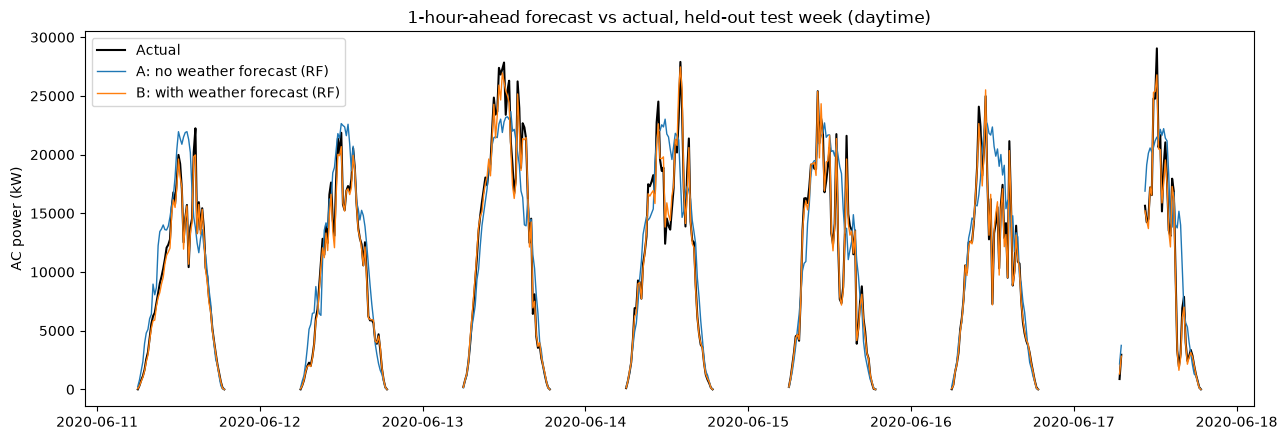

In [4]:
full = pd.date_range(ref["target_time"].min(), ref["target_time"].max(), freq="15min")
as_series = lambda g, col: pd.Series(g[col].values, index=g["target_time"].values).reindex(full)
fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(full, as_series(ref, "y_true"), color="k", lw=1.5, label="Actual")
for setup, color, lab in [("A_lagged_only", "tab:blue", "A: no weather forecast"),
                          ("B_with_forecast", "tab:orange", "B: with weather forecast")]:
    g = P[(P["setup"] == setup) & (P["model"] == chosen[setup])]
    ax.plot(full, as_series(g, "y_pred"), color=color, lw=1, label=f"{lab} ({chosen[setup]})")
ax.set(ylabel="AC power (kW)", title="1-hour-ahead forecast vs actual, held-out test week (daytime)")
ax.legend()
fig.tight_layout()
fig.savefig(FIG / "results_pred_vs_actual.png", dpi=150)

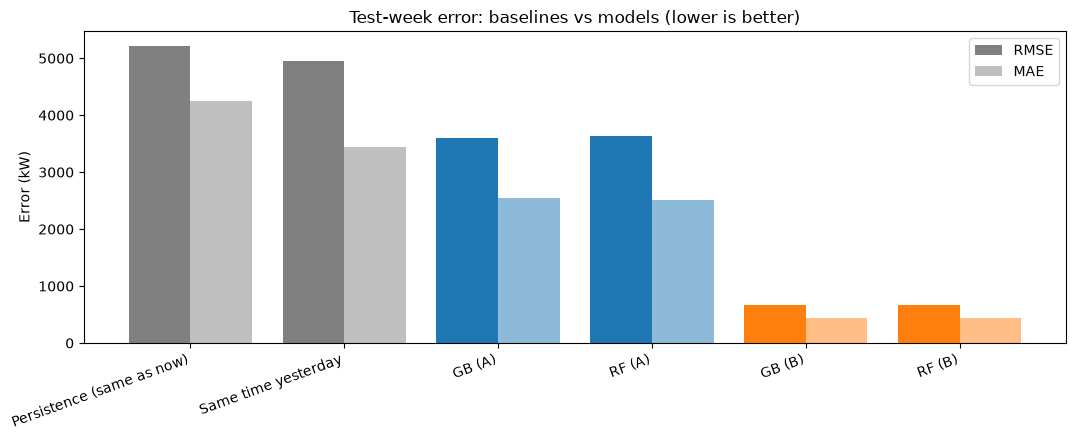

In [5]:
order = M.copy()
order["label"] = np.where(order["setup"] == "baseline", order["model"],
                          order["model"] + " (" + order["setup"].str[0] + ")")
colors = order["setup"].map({"baseline": "gray", "A_lagged_only": "tab:blue", "B_with_forecast": "tab:orange"})
xpos = np.arange(len(order))
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.bar(xpos - 0.2, order["RMSE"], width=0.4, color=colors, label="RMSE")
ax.bar(xpos + 0.2, order["MAE"], width=0.4, color=colors, alpha=0.5, label="MAE")
ax.set_xticks(xpos)
ax.set_xticklabels(order["label"], rotation=20, ha="right")
ax.set(ylabel="Error (kW)", title="Test-week error: baselines vs models (lower is better)")
ax.legend()
fig.tight_layout()
fig.savefig(FIG / "results_model_comparison.png", dpi=150)


Figures saved to C:\Users\VICTUS\Documents\College\Semester 3\Machine Learning\Solar Power Generation Data\figures


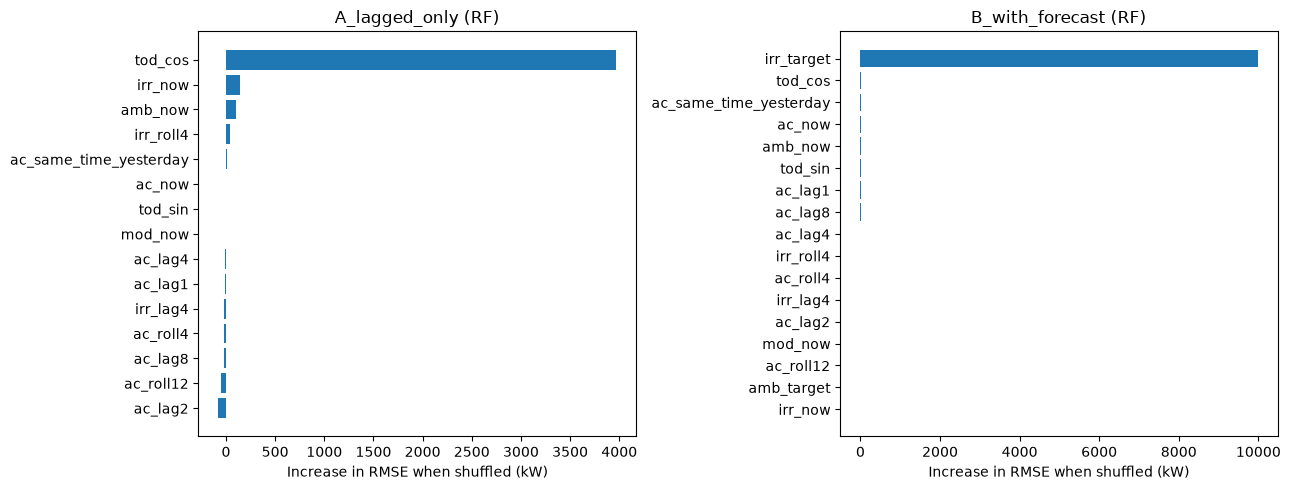

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (setup, feats) in zip(axes, sets.items()):
    mdl = joblib.load(OUT / f"model_{setup}_{chosen[setup]}.joblib")
    pi = permutation_importance(mdl, X.loc[ref.index, feats], X.loc[ref.index, "y"], n_repeats=10,
                                random_state=42, scoring="neg_root_mean_squared_error", n_jobs=1)
    imp = pd.Series(pi.importances_mean, index=feats).sort_values()
    ax.barh(imp.index, imp.values)
    ax.set(xlabel="Increase in RMSE when shuffled (kW)", title=f"{setup} ({chosen[setup]})")
fig.tight_layout()
fig.savefig(FIG / "results_feature_importance.png", dpi=150)
print(f"\nFigures saved to {FIG}")